Construct MA(q) and AR(q) series

In [109]:
import pandas as pd
import numpy as np

T = 500
ma_orders = [1, 2, 4, 20]
ma_coefficients = [1.0, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05, 0.01, 0.005, 0.005, 0.005]

ar_orders = [1, 2, 3, 10]
ar_coefficients = [0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625, 0.0078125, 0.00390625, 0.001953125, 0.0009765625]

# Generate T periods of white noise
df_data = pd.DataFrame({
	'time': range(1, T + 1),
	'epsilon_t': np.random.normal(0, 1, T)  # Generate T random values from a normal distribution
})


21


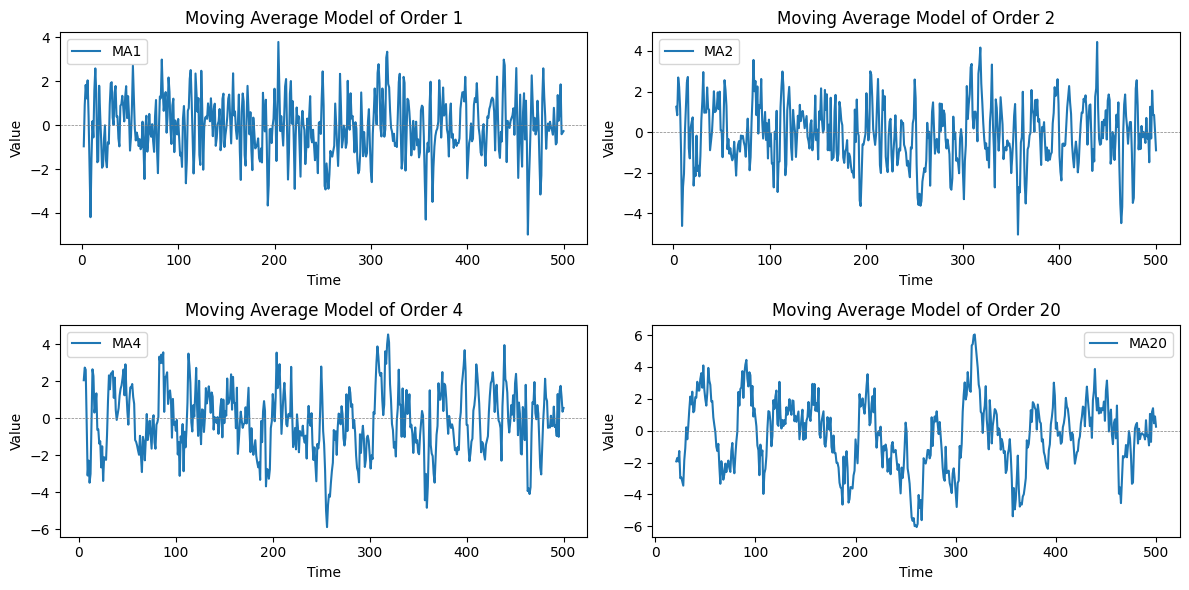

In [57]:
import matplotlib.pyplot as plt
# For each order of MA and RA, we will create a new column in the dataframe with the name "MA{ma_order}_AR{ar_order}"
# Generate data of 100 time periods with random values for each order in the respective lists.
print(len(ma_coefficients))
for order in ma_orders:
	# Set each column to a y_t MA model, based on MA coefficients and the previous values of the "value" column.
	# ex: y_MA2 = 1.0 * value_t + 0.5 * value_{t-1} + 0.3 * value_{t-2}
	# So we need to take the first (order + 1) coefficients from the ma_coefficients list, and use them to calculate the new column.
	df_data[f'y_MA{order}'] = df_data['epsilon_t'].rolling(window=order + 1).apply(
		lambda x: np.sum(x * ma_coefficients[:order + 1][::-1])
		, raw=True)


# Plot the 4 new MA columns in a 2x2 plot
plt.figure(figsize=(12, 6))
for [index, order] in enumerate(ma_orders):
	plt.subplot(2, 2, index + 1)
	plt.plot(df_data['time'], df_data[f'y_MA{order}'], label=f'MA{order}')
	plt.title(f'Moving Average Model of Order {order}')
	plt.xlabel('Time')
	plt.ylabel('Value')
	plt.legend()
	plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

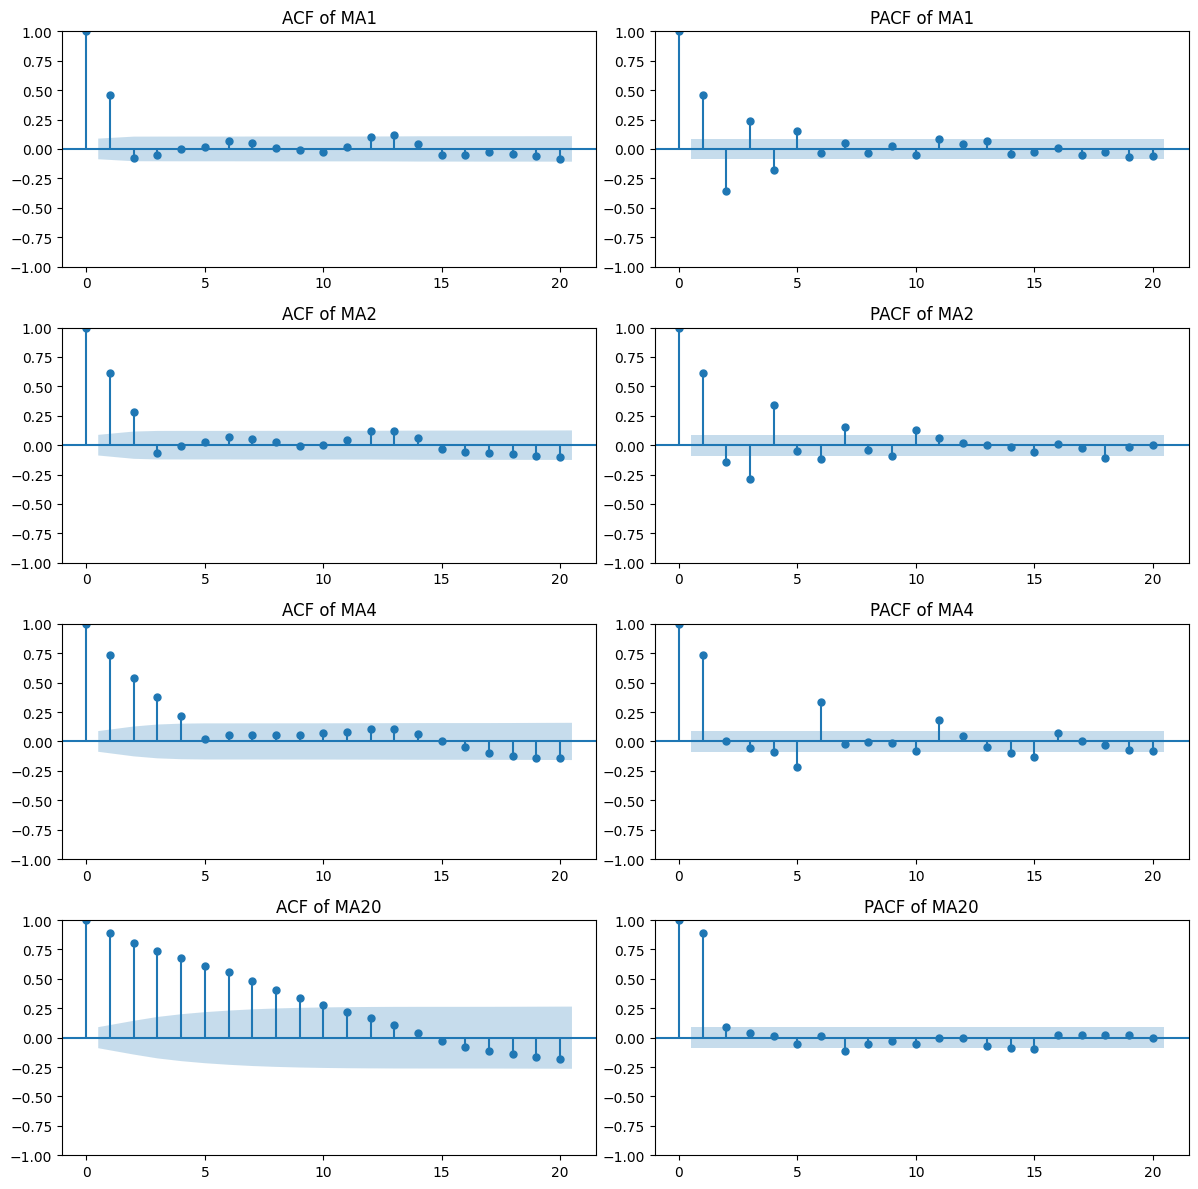

In [58]:
# Plot ACFs and PACFs for each of the 4 MA columns
# Use a 4x2 plot to show ACF and PACF for each of the 4 MA columns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12, 12))

for [index, order] in enumerate(ma_orders):
	plt.subplot(4, 2, index * 2 + 1)
	plot_acf(df_data[f'y_MA{order}'].dropna(), ax=plt.gca(), lags=20)
	plt.title(f'ACF of MA{order}')
	plt.subplot(4, 2, index * 2 + 2)
	plot_pacf(df_data[f'y_MA{order}'].dropna(), ax=plt.gca(), lags=20)
	plt.title(f'PACF of MA{order}')
plt.tight_layout()
plt.show()

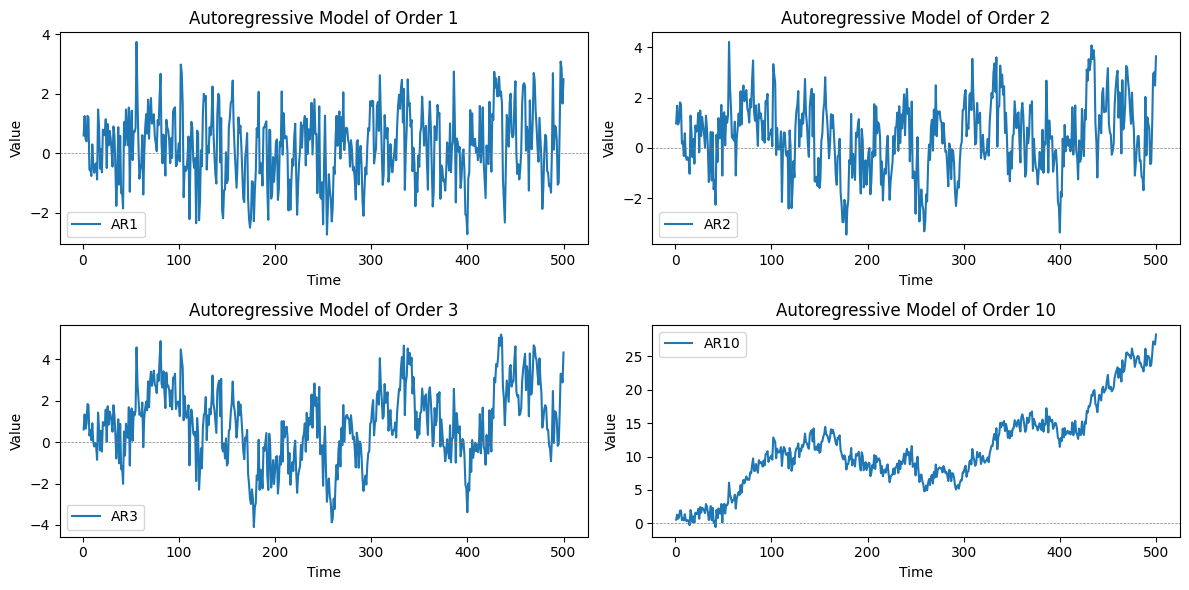

In [110]:
import matplotlib.pyplot as plt
# For each order of MA and RA, we will create a new column in the dataframe with the name "MA{ma_order}_AR{ar_order}"
# Generate data of 100 time periods with random values for each order in the respective lists.
for order in ar_orders:
	# Set each column to a y_t AR model, based on AR coefficients and its previous values
	# ex: y_AR2 = 0.5 * y_AR2_{t-1} + 0.3 * y_AR2_{t-2} + epsilon_t
	epsilon_t = df_data['epsilon_t']
	y_t_series = []
	for t in range(order):
		y_t_series.append(epsilon_t[t])

	for t in range(T):
		prev_values = y_t_series[t: t + order][::-1]  				# Get the previous 'order' values in reverse order
		coefficients = ar_coefficients[:order]  					# Get the first 'order' coefficients
		product = [phi * y for phi, y in zip(coefficients, prev_values)]  						# Element-wise multiplication
		y_t = sum(product) + epsilon_t[t]  	# Calculate the new value based on AR model
		y_t_series.append(y_t) 
	y_t_truncated = y_t_series[order:]
	
	df_data[f'y_AR{order}'] = y_t_truncated
	

# Plot the 4 new AR columns in a 3x2 plot
plt.figure(figsize=(12, 6))
for order in ar_orders:
	plt.subplot(2, 2, ar_orders.index(order) + 1)
	plt.plot(df_data['time'], df_data[f'y_AR{order}'], label=f'AR{order}')
	plt.title(f'Autoregressive Model of Order {order}')
	plt.xlabel('Time')
	plt.ylabel('Value')
	plt.legend()
	plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

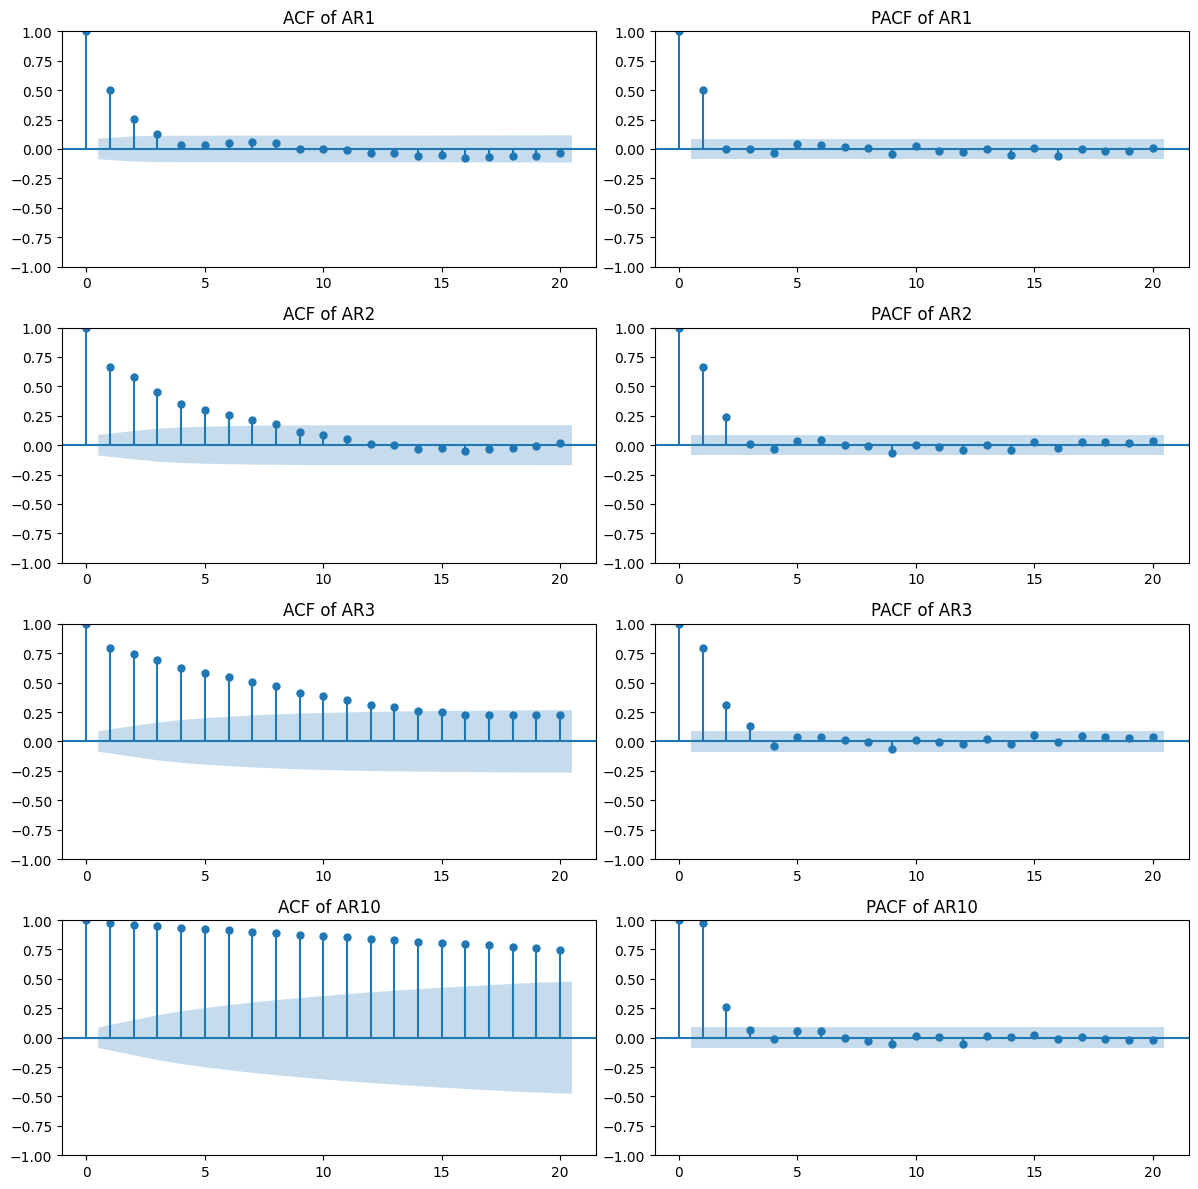

In [111]:
# Plot ACFs and PACFs for each of the 4 AR columns
# Use a 4x2 plot to show ACF and PACF for each of the 4 AR columns

plt.figure(figsize=(12, 12))
for [index, order] in enumerate(ar_orders):
	plt.subplot(4, 2, index * 2 + 1)
	plot_acf(df_data[f'y_AR{order}'].dropna(), ax=plt.gca(), lags=20)
	plt.title(f'ACF of AR{order}')
	plt.subplot(4, 2, index * 2 + 2)
	plot_pacf(df_data[f'y_AR{order}'].dropna(), ax=plt.gca(), lags=20)
	plt.title(f'PACF of AR{order}')
plt.tight_layout()
plt.show()

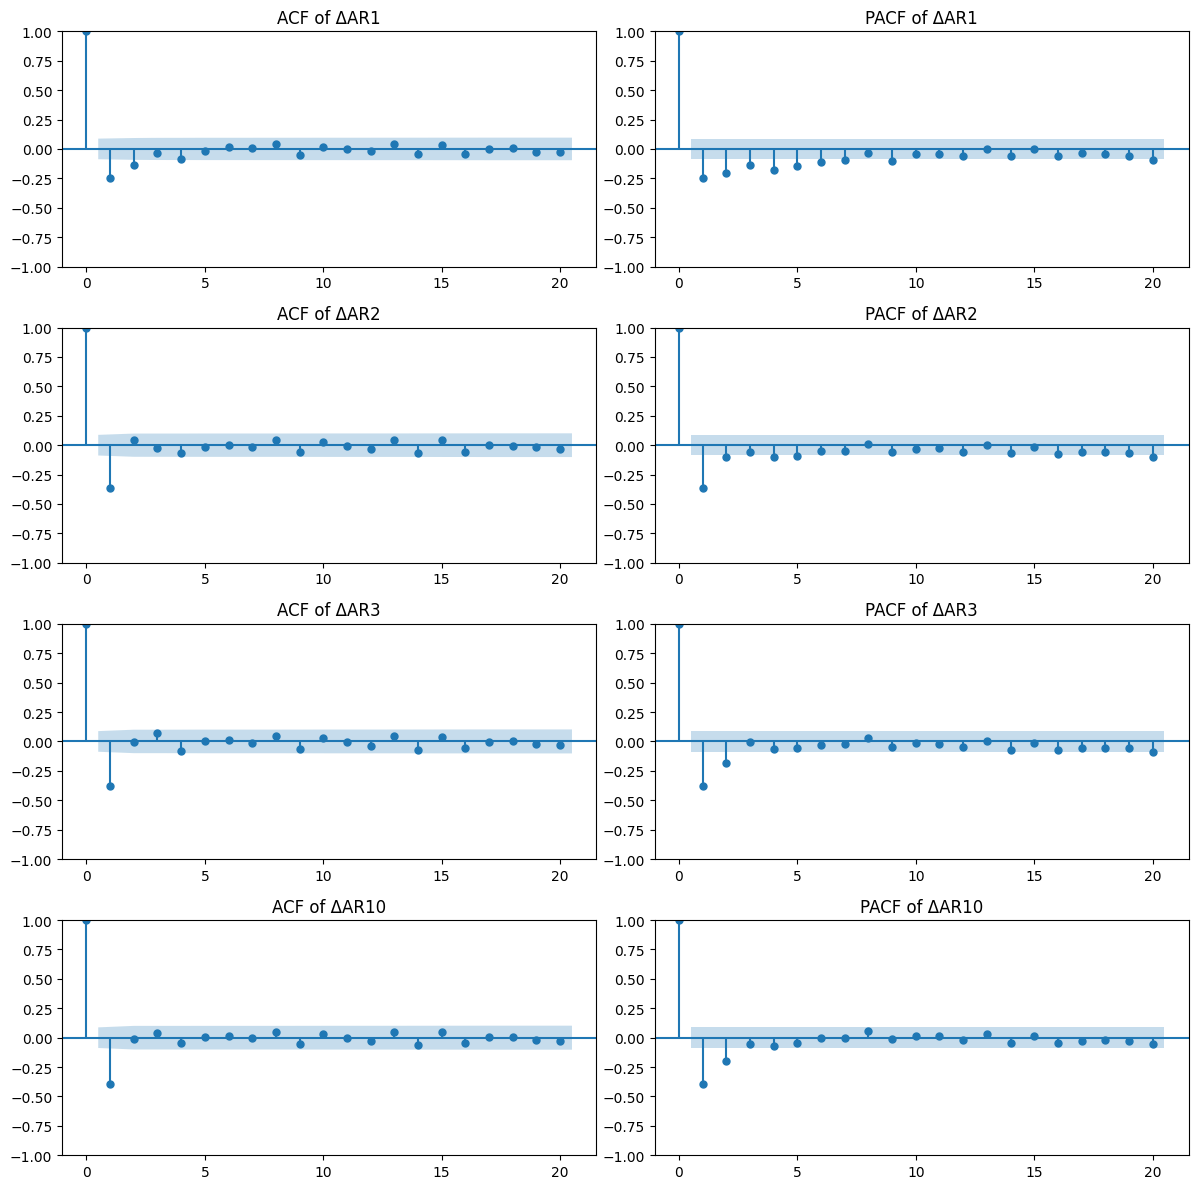

In [113]:
# Take first differences of the AR columsn to turn them stationary

for order in ar_orders:
	df_data[f'y_AR{order}_diff'] = df_data[f'y_AR{order}'].diff()

# Plot ACFs and PACFs for each of the 4 AR columns after differencing
# Use a 4x2 plot to show ACF and PACF for each of the 4 AR columns after differencing
plt.figure(figsize=(12, 12))
for [index, order] in enumerate(ar_orders):
	plt.subplot(4, 2, index * 2 + 1)
	plot_acf(df_data[f'y_AR{order}_diff'].dropna(), ax=plt.gca(), lags=20)
	plt.title(f'ACF of ΔAR{order}')
	plt.subplot(4, 2, index * 2 + 2)
	plot_pacf(df_data[f'y_AR{order}_diff'].dropna(), ax=plt.gca(), lags=20)
	plt.title(f'PACF of ΔAR{order}')
plt.tight_layout()
plt.show()